# Demand Forecasting by Cluster

In the previous step, demand patterns were segmented using Gaussian Mixture Models based on statistical characteristics extracted from each SKU's sales history. This clustering process allows products with similar demand behavior to be grouped together, regardless of their original category.

The rationale behind this approach is that different demand patterns often require different forecasting strategies. Products with stable demand, seasonal behavior, intermittent sales, or high variability exhibit distinct statistical properties that can be difficult for a single model to capture effectively.

In this section, a separate forecasting model will be trained for each identified cluster. By specializing models on homogeneous demand groups, we aim to improve forecast accuracy and better capture the underlying dynamics of each demand pattern. These forecasts will later serve as inputs for the inventory optimization and replenishment policy simulation stages of the project.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from matplotlib import pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

pd.set_option("display.max_columns", None)
np.random.seed(42)

def create_features(df):
    """
    Create forecasting features for daily SKU-level demand modeling.

    The target variable is daily sales. Features are created using only
    information available before the prediction date.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with daily SKU-level data.

    Returns
    -------
    pd.DataFrame
        Dataframe with model features.
    """

    df_features = df.copy()
    df_features["date"] = pd.to_datetime(df_features["date"])
    df_features = df_features.sort_values(["sku_id", "date"])

    # Calendar features
    df_features["month"] = df_features["date"].dt.month
    df_features["quarter"] = df_features["date"].dt.quarter
    df_features["week_of_year"] = df_features["date"].dt.isocalendar().week.astype(int)
    df_features["day_of_year"] = df_features["date"].dt.dayofyear

    df_features["month_sin"] = np.sin(2 * np.pi * df_features["month"] / 12)
    df_features["month_cos"] = np.cos(2 * np.pi * df_features["month"] / 12)

    # Lag features
    for lag in [1, 7, 14, 28]:
        df_features[f"lag_{lag}"] = (
            df_features
            .groupby("sku_id")["sales"]
            .shift(lag)
        )

    # Rolling features using only past values
    for window in [7, 28, 90]:
        df_features[f"rolling_mean_{window}"] = (
            df_features
            .groupby("sku_id")["sales"]
            .shift(1)
            .rolling(window=window)
            .mean()
            .reset_index(level=0, drop=True)
        )

    for window in [28, 90]:
        df_features[f"rolling_std_{window}"] = (
            df_features
            .groupby("sku_id")["sales"]
            .shift(1)
            .rolling(window=window)
            .std()
            .reset_index(level=0, drop=True)
        )

    # Lagged inventory to avoid leakage
    df_features["inventory_end_lag_1"] = (
        df_features
        .groupby("sku_id")["inventory_end"]
        .shift(1)
    )

    # Lagged stockout flag
    df_features["stockout_flag_lag_1"] = (
        df_features
        .groupby("sku_id")["stockout_flag"]
        .shift(1)
    )

    # Days since last stockout
    def calculate_days_since_stockout(stockout_series):
        days_since = []
        counter = np.nan

        for value in stockout_series:
            if value == 1:
                counter = 0
            else:
                if pd.isna(counter):
                    counter = np.nan
                else:
                    counter += 1

            days_since.append(counter)

        return pd.Series(days_since, index=stockout_series.index)

    df_features["days_since_stockout"] = (
        df_features
        .groupby("sku_id")["stockout_flag"]
        .transform(calculate_days_since_stockout)
        .groupby(df_features["sku_id"])
        .shift(1)
    )

    df_features["days_since_stockout"] = df_features["days_since_stockout"].fillna(0)

    # Remove rows where lagged features are not available
    df_features = df_features.dropna(subset=['month', 'quarter', 'week_of_year',
       'day_of_year', 'month_sin', 'month_cos', 'lag_1', 'lag_7', 'lag_14',
       'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'rolling_mean_90',
       'rolling_std_28', 'rolling_std_90', 'inventory_end_lag_1',
       'stockout_flag_lag_1', 'days_since_stockout']
    ).reset_index(drop=True)

    return df_features

The selected feature set captures the main characteristics that differentiate demand patterns in supply chain environments. Lag features provide information about recent demand behavior, while rolling means summarize the average demand level over short, medium and long-term horizons. Products with steady demand tend to exhibit stable lag values and rolling averages, whereas highly variable products show larger fluctuations across these features. Similarly, rolling standard deviations quantify demand volatility and help distinguish stable products from those with noisy or unpredictable demand patterns.

Seasonal behavior is captured through the calendar variables and cyclical month encodings, allowing the model to recognize recurring demand patterns throughout the year. In addition, inventory-related features such as lagged inventory levels, stockout indicators, and days since the last stockout provide context about demand censoring and supply constraints. Sparse or intermittent products can be identified through the combination of low lag values, extended periods without sales, and characteristic rolling statistics. Together, these features provide a comprehensive representation of demand level, variability, seasonality, intermittency, and inventory dynamics, making them well suited for separating the different demand patterns present in the dataset.


In [52]:
df = pd.read_csv("../data/clusters.csv", parse_dates=['date'])
print(df.shape)
df.head()

(43840, 15)


,date,sku_id,category,demand_type,sales,inventory_end,replenishment_qty,stockout_flag,base_demand,lead_time,safety_stock,reorder_point,order_up_to_level,initial_inventory,cluster
0,2020-01-01,1,group_1_steady,steady,33,384,0,0,38,4,38,190,456,417,0
1,2020-01-02,1,group_1_steady,steady,31,353,0,0,38,4,38,190,456,417,0
2,2020-01-03,1,group_1_steady,steady,42,311,0,0,38,4,38,190,456,417,0
3,2020-01-04,1,group_1_steady,steady,43,268,0,0,38,4,38,190,456,417,0
4,2020-01-05,1,group_1_steady,steady,24,244,0,0,38,4,38,190,456,417,0


In [53]:
df_features = create_features(df)
print(df_features.shape)
df_features.head()

(42040, 33)


,date,sku_id,category,demand_type,sales,inventory_end,replenishment_qty,stockout_flag,base_demand,lead_time,safety_stock,reorder_point,order_up_to_level,initial_inventory,cluster,month,quarter,week_of_year,day_of_year,month_sin,month_cos,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,rolling_mean_90,rolling_std_28,rolling_std_90,inventory_end_lag_1,stockout_flag_lag_1,days_since_stockout
0,2020-03-31,1,group_1_steady,steady,43,106,0,0,38,4,38,190,456,417,0,3,1,14,91,1.000000,6.123234e-17,42.0,34.0,31.0,40.0,37.714286,37.357143,37.600000,5.716864,5.884277,149.0,0.0,0.0
1,2020-04-01,1,group_1_steady,steady,40,66,0,0,38,4,38,190,456,417,0,4,2,14,92,0.866025,-5.000000e-01,43.0,24.0,41.0,45.0,39.000000,37.464286,37.711111,5.795798,5.890851,106.0,0.0,0.0
2,2020-04-02,1,group_1_steady,steady,44,22,0,0,38,4,38,190,456,417,0,4,2,14,93,0.866025,-5.000000e-01,40.0,45.0,45.0,44.0,41.285714,37.285714,37.811111,5.629664,5.851907,66.0,0.0,0.0
3,2020-04-03,1,group_1_steady,steady,41,288,307,0,38,4,38,190,456,417,0,4,2,14,94,0.866025,-5.000000e-01,44.0,35.0,37.0,33.0,41.142857,37.285714,37.833333,5.629664,5.871757,22.0,0.0,0.0
4,2020-04-04,1,group_1_steady,steady,22,266,0,0,38,4,38,190,456,417,0,4,2,14,95,0.866025,-5.000000e-01,41.0,42.0,29.0,33.0,42.000000,37.571429,37.811111,5.607063,5.855746,288.0,0.0,0.0


In [54]:
df_features.columns

Index(['date', 'sku_id', 'category', 'demand_type', 'sales', 'inventory_end',
       'replenishment_qty', 'stockout_flag', 'base_demand', 'lead_time',
       'safety_stock', 'reorder_point', 'order_up_to_level',
       'initial_inventory', 'cluster', 'month', 'quarter', 'week_of_year',
       'day_of_year', 'month_sin', 'month_cos', 'lag_1', 'lag_7', 'lag_14',
       'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'rolling_mean_90',
       'rolling_std_28', 'rolling_std_90', 'inventory_end_lag_1',
       'stockout_flag_lag_1', 'days_since_stockout'],
      dtype='object')

In [55]:
validation_date = '2023-09-01'
test_date = '2024-07-16'

df_train = df_features[df_features.date < validation_date].copy()
df_valid = df_features[(df_features.date >= validation_date) & (df_features.date < test_date)].copy()
df_test = df_features[df_features.date >= test_date].copy()

num_features = [ 'quarter', 'week_of_year',
    'day_of_year', 'month_sin', 'month_cos', 'lag_1', 'lag_7', 'lag_14',
    'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'rolling_mean_90',
    'rolling_std_28', 'rolling_std_90', 'inventory_end_lag_1',
    'stockout_flag_lag_1', 'days_since_stockout']

cat_features = ['sku_id']
features = num_features + cat_features

### Model Cluster 0

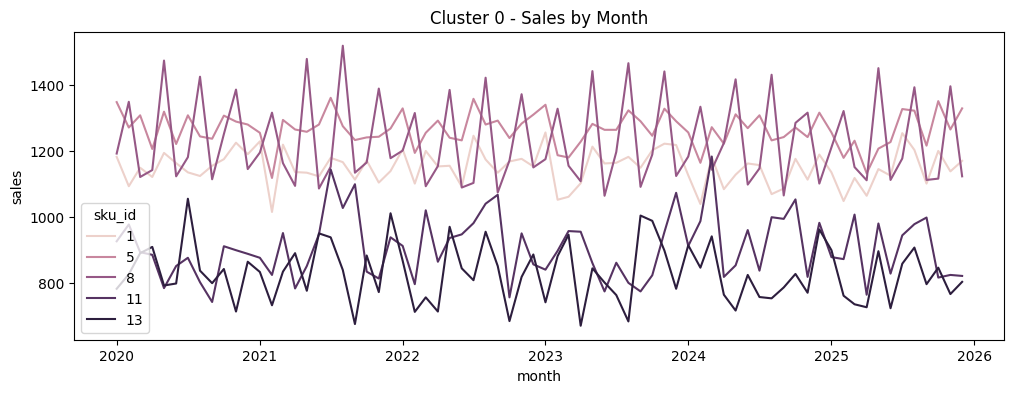

In [56]:

def plot_cluster(cluster=0):

    fig, ax = plt.subplots(figsize=(12,4))

    df_month = (
        df[df.cluster == cluster]
        .assign(month=df[df.cluster == cluster]["date"].dt.to_period("M").dt.to_timestamp())
        .groupby(["month", "sku_id"], as_index=False)["sales"]
        .sum()
    )

    sns.lineplot(
        data=df_month,
        x="month",
        y="sales",
        hue="sku_id"
    )

    plt.title(f'Cluster {cluster} - Sales by Month')
    plt.show()

plot_cluster()

In [57]:
df_train[df_train.cluster == 0].groupby('sku_id').agg({
    'sales': ['min', 'max', 'mean', 'median', 'std'],
    'inventory_end': ['min', 'max', 'mean', 'median', 'std'],
    'lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'lag_7': ['min', 'max', 'mean', 'median', 'std'],
    'lag_14': ['min', 'max', 'mean', 'median', 'std'],
    'lag_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_7': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_90': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_std_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_std_90': ['min', 'max', 'mean', 'median', 'std'],
    'inventory_end_lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'stockout_flag_lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'days_since_stockout': ['min', 'max', 'mean', 'median', 'std']
})

sales                                  inventory_end                   \
         min max       mean median        std           min  max        mean   
sku_id                                                                         
1         16  60  37.984788   38.0   7.034525            11  358  180.226581   
5         16  71  41.603683   42.0   7.476610            25  378  205.878303   
8         13  68  40.546037   41.0   8.123624             4  386  197.591673   
11         0  91  29.510809   29.0  19.205203             0  320  145.999199   
13         0  91  27.232986   27.0  16.765091             0  383  185.663731   

                         lag_1                                    lag_7        \
       median        std   min   max       mean median        std   min   max   
sku_id                                                                          
1       180.0  83.647061  16.0  60.0  37.974380   38.0   7.018929  16.0  60.0   
5       207.0  91.599898  16.0  71.0  41.591673   42.0   7.465506  16.0  71.0   
8       198.0  89.526612  13.0  68.0  40.535629   41.0   8.118546  13.0  68.0   
11      146.0  71.043510   0.0  91.0  29.483587   29.0  19.215835   0.0  91.0   
13      187.0  71.343679   0.0  91.0  27.204163   27.0  16.760304   0.0  91.0   

                                    lag_14                                     \
             mean median        std    min   max       mean median        std   
sku_id                                                                          
1       37.948759   38.0   7.013535   16.0  60.0  37.956765   38.0   7.018272   
5       41.558046   42.0   7.456715   16.0  71.0  41.571657   42.0   7.441322   
8       40.483587   41.0   8.118410   13.0  68.0  40.421137   40.0   8.101840   
11      29.523619   29.0  19.266384    0.0  91.0  29.520416   29.0  19.289248   
13      27.317854   27.0  16.737386    0.0  91.0  27.339472   27.0  16.756889   

       lag_28                                    rolling_mean_7             \
          min   max       mean median        std            min        max   
sku_id                                                                       
1        16.0  60.0  37.949560   38.0   7.010284      28.285714  47.428571   
5        16.0  71.0  41.570857   42.0   7.408739      32.714286  50.571429   
8        13.0  68.0  40.293034   40.0   8.076892      26.285714  53.428571   
11        0.0  91.0  29.598078   29.0  19.294285       7.142857  50.571429   
13        0.0  91.0  27.398719   27.0  16.799187       7.857143  45.571429   

                                       rolling_mean_28                        \
             mean     median       std             min        max       mean   
sku_id                                                                         
1       37.961912  38.000000  2.756392       33.321429  41.714286  37.956251   
5       41.579206  41.571429  2.926260       37.392857  45.035714  41.575346   
8       40.512410  40.714286  5.869438       32.000000  49.321429  40.410957   
11      29.517328  29.571429  6.976485       22.178571  41.535714  29.552671   
13      27.255176  27.285714  6.135631       18.892857  35.607143  27.348393   

                            rolling_mean_90                                   \
           median       std             min        max       mean     median   
sku_id                                                                         
1       37.857143  1.314774       35.733333  39.788889  37.957379  37.955556   
5       41.428571  1.388566       39.888889  43.200000  41.633316  41.644444   
8       40.428571  4.786730       38.422222  41.833333  40.432079  40.444444   
11      29.428571  3.278545       23.344444  35.644444  29.663429  29.488889   
13      27.214286  3.226509       23.944444  30.477778  27.426777  27.422222   

                 rolling_std_28                                             \
             std            min        max       mean     median       std   
sku_i

In [58]:
def run_model(cluster=0):

    X_train = df_train[df_train.cluster == cluster][features]
    y_train = df_train[df_train.cluster == cluster]['sales']
    X_valid = df_valid[df_valid.cluster == cluster][features]
    y_valid = df_valid[df_valid.cluster == cluster]['sales']
    X_test = df_test[df_test.cluster == cluster][features]
    y_test = df_test[df_test.cluster == cluster]['sales']

    model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=100,
        early_stopping_rounds=200
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        cat_features=cat_features,
        use_best_model=True
    )

    valid_pred = model.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))

    test_pred = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    print(f"\nValidation RMSE: {valid_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")

    return test_rmse, model

std0, model0 = run_model(0)

0:	learn: 13.9758495	test: 13.8474021	best: 13.8474021 (0)	total: 3.14ms	remaining: 3.13s
100:	learn: 12.2015140	test: 12.7836717	best: 12.7744685 (80)	total: 244ms	remaining: 2.17s
200:	learn: 11.6242345	test: 12.8051941	best: 12.7744685 (80)	total: 453ms	remaining: 1.8s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 12.77446854
bestIteration = 80

Shrink model to first 81 iterations.

Validation RMSE: 12.7745
Test RMSE: 12.4283


### Model cluster 1

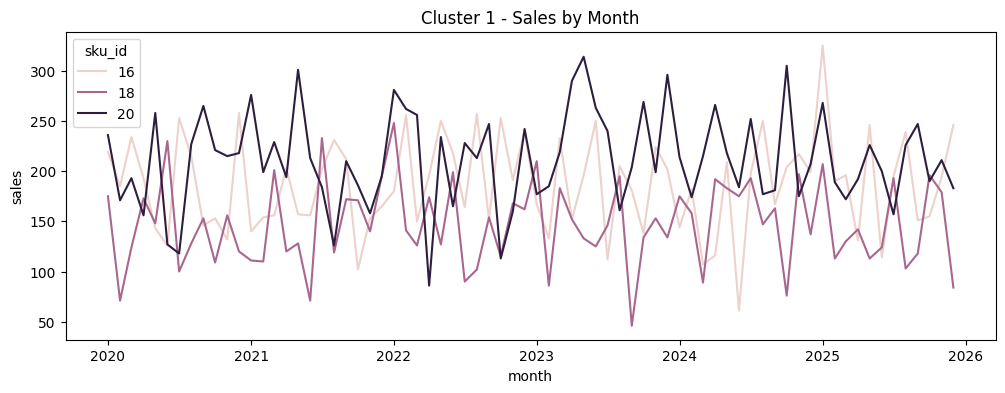

In [59]:
plot_cluster(1)

In [60]:
df_train[df_train.cluster == 1].groupby('sku_id').agg({
    'sales': ['min', 'max', 'mean', 'median', 'std'],
    'inventory_end': ['min', 'max', 'mean', 'median', 'std'],
    'lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'lag_7': ['min', 'max', 'mean', 'median', 'std'],
    'lag_14': ['min', 'max', 'mean', 'median', 'std'],
    'lag_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_7': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_90': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_std_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_std_90': ['min', 'max', 'mean', 'median', 'std'],
    'inventory_end_lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'stockout_flag_lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'days_since_stockout': ['min', 'max', 'mean', 'median', 'std']
})

sales                                 inventory_end                  \
         min max      mean median        std           min  max       mean   
sku_id                                                                       
16         0  31  6.100881    0.0   9.046944             0  164  79.537230   
18         0  29  4.925540    0.0   8.220132             0  113  54.803042   
20         0  37  6.895116    0.0  10.743336             0  171  81.967174   

                         lag_1                                   lag_7        \
       median        std   min   max      mean median        std   min   max   
sku_id                                                                         
16       80.0  36.141843   0.0  31.0  6.100881    0.0   9.046944   0.0  31.0   
18       55.0  30.201879   0.0  29.0  4.925540    0.0   8.220132   0.0  29.0   
20       82.0  40.840250   0.0  37.0  6.895116    0.0  10.743336   0.0  37.0   

                                   lag_14                                    \
            mean median        std    min   max      mean median        std   
sku_id                                                                        
16      6.099279    0.0   9.044127    0.0  31.0  6.082466    0.0   9.051425   
18      4.924740    0.0   8.222708    0.0  29.0  4.885508    0.0   8.188124   
20      6.914331    0.0  10.752081    0.0  37.0  6.925540    0.0  10.759316   

       lag_28                                   rolling_mean_7             \
          min   max      mean median        std            min        max   
sku_id                                                                      
16        0.0  31.0  6.129704    0.0   9.070459            0.0  15.571429   
18        0.0  29.0  4.864692    0.0   8.181834            0.0  16.142857   
20        0.0  37.0  6.920737    0.0  10.750937            0.0  21.142857   

                                     rolling_mean_28                       \
            mean    median       std             min        max      mean   
sku_id                                                                      
16      6.091273  5.857143  3.357660        1.500000  10.964286  6.095047   
18      4.927828  5.000000  3.099160        1.642857   8.821429  4.897489   
20      6.900377  6.571429  3.743645        2.428571  11.642857  6.915304   

                           rolling_mean_90                                 \
          median       std             min        max      mean    median   
sku_id                                                                      
16      6.035714  1.628743        3.944444   7.866667  6.143421  6.133333   
18      4.785714  1.414371        3.322222   7.233333  4.853670  4.800000   
20      6.857143  1.725236        4.755556  10.011111  6.897562  6.811111   

                 rolling_std_28                                             \
             std            min        max       mean     median       std   
sku_id                                                                       
16      0.757543       4.434712  11.166607   9.006053   9.113337  1.005445   
18      0.709120       5.158339  10.464857   8.159315   8.250060  1.016933   
20      1.072477       7.225030  13.152142  10.741670  10.844744  1.154852   

       rolling_std_90                                             \
                  min        max       mean     median       std   
sku_id                                                             
16           7.628099  10.099282   9.065864   9.110372  0.427850   
18           6.837520   9.440820   8.167951   8.226362  0.480310   
20           8.867565  11.864639  10.718144  10.769495  0.577155   

       inventory_end_lag_1                                      \
                       min    max       mean median        std   
sku_id                                                           
16                     0.0  164.0  79.587670   80.0  36.159908   
18                     0.0  113.0  54.774219   55.0

In [61]:
std1, model1 = run_model(1)

0:	learn: 9.4147273	test: 9.5667079	best: 9.5667079 (0)	total: 6.06ms	remaining: 6.05s
100:	learn: 9.0487979	test: 9.5408010	best: 9.5164091 (68)	total: 234ms	remaining: 2.08s
200:	learn: 8.7868775	test: 9.5888891	best: 9.5164091 (68)	total: 435ms	remaining: 1.73s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 9.516409091
bestIteration = 68

Shrink model to first 69 iterations.

Validation RMSE: 9.5164
Test RMSE: 9.4088


### Model Cluster 2

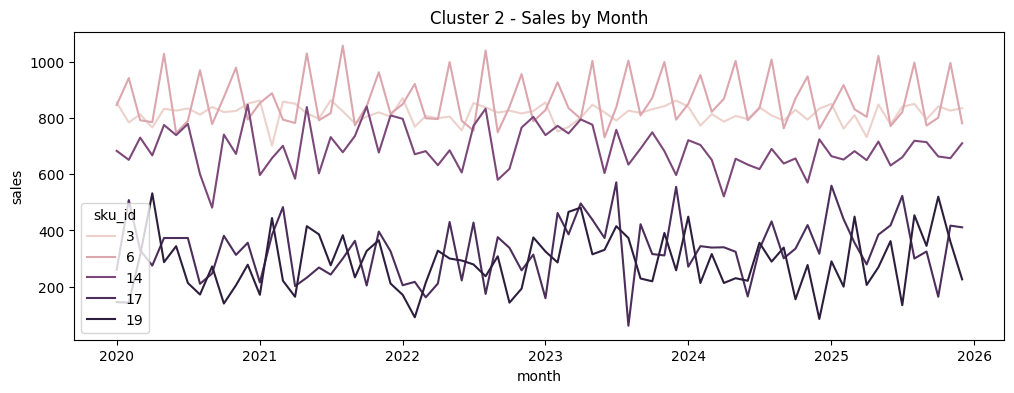

In [62]:
plot_cluster(2)

In [63]:
df_train[df_train.cluster == 2].groupby('sku_id').agg({
    'sales': ['min', 'max', 'mean', 'median', 'std'],
    'inventory_end': ['min', 'max', 'mean', 'median', 'std'],
    'lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'lag_7': ['min', 'max', 'mean', 'median', 'std'],
    'lag_14': ['min', 'max', 'mean', 'median', 'std'],
    'lag_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_7': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_90': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_std_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_std_90': ['min', 'max', 'mean', 'median', 'std'],
    'inventory_end_lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'stockout_flag_lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'days_since_stockout': ['min', 'max', 'mean', 'median', 'std']
})

sales                                  inventory_end                   \
         min max       mean median        std           min  max        mean   
sku_id                                                                         
3         11  44  26.791833   27.0   4.882258             2  233  121.795837   
6         10  46  28.354684   28.0   5.745112             5  282  150.016813   
14         0  71  23.240993   23.0  14.165077             0  302  139.498799   
17         0  74  10.246597    0.0  21.034123             0  373  184.113691   
19         0  78   9.578062    0.0  20.791406             0  237  121.981585   

                         lag_1                                    lag_7        \
       median        std   min   max       mean median        std   min   max   
sku_id                                                                          
3       122.0  58.686251  11.0  44.0  26.792634   27.0   4.883358  11.0  44.0   
6       150.0  63.727325  10.0  46.0  28.345076   28.0   5.742349  10.0  45.0   
14      139.0  60.228533   0.0  71.0  23.226581   23.0  14.175493   0.0  71.0   
17      187.0  85.894491   0.0  74.0  10.246597    0.0  21.034123   0.0  74.0   
19      126.0  67.429537   0.0  78.0   9.623699    0.0  20.832881   0.0  78.0   

                                    lag_14                                     \
             mean median        std    min   max       mean median        std   
sku_id                                                                          
3       26.760608   27.0   4.874336   11.0  44.0  26.773419   27.0   4.864912   
6       28.312250   28.0   5.735225   10.0  45.0  28.265012   28.0   5.729148   
14      23.230584   23.0  14.143201    0.0  71.0  23.295436   23.0  14.225011   
17      10.372298    0.0  21.128914    0.0  74.0  10.413931    0.0  21.159138   
19       9.623699    0.0  20.832881    0.0  78.0   9.558847    0.0  20.748531   

       lag_28                                    rolling_mean_7             \
          min   max       mean median        std            min        max   
sku_id                                                                       
3        11.0  44.0  26.775020   27.0   4.856909      20.857143  32.000000   
6        10.0  44.0  28.191353   28.0   5.678151      18.000000  37.857143   
14        0.0  71.0  23.346677   23.0  14.231344       6.714286  39.000000   
17        0.0  74.0  10.461970    0.0  21.203540       0.000000  32.142857   
19        0.0  78.0   9.529223    0.0  20.734107       0.000000  33.285714   

                                       rolling_mean_28                        \
             mean     median       std             min        max       mean   
sku_id                                                                         
3       26.777994  26.857143  1.984596       24.500000  29.142857  26.779824   
6       28.334325  28.571429  4.115544       21.500000  34.571429  28.262010   
14      23.217889  23.428571  5.107196       13.464286  30.928571  23.274448   
17      10.282969   8.285714  7.709151        0.000000  22.000000  10.400549   
19       9.623699   8.285714  7.596004        0.000000  20.714286   9.589500   

                            rolling_mean_90                                   \
           median       std             min        max       mean     median   
sku_id                                                                         
3       26.750000  0.947426       25.811111  27.955556  26.803256  26.855556   
6       28.285714  3.321610       26.955556  29.166667  28.292954  28.311111   
14      23.428571  2.823076       19.344444  26.622222  23.280838  23.222222   
17      10.000000  3.602238        6.488889  15.522222  10.409892  10.155556   
19       9.714286  3.574551        4.644444  15.011111   9.426136   9.277778   

                 rolling_std_28                                             \
             std            min        max       mean     median       std   
sku_i

In [64]:
std2, model2 = run_model(2)

0:	learn: 16.9062386	test: 17.0047144	best: 17.0047144 (0)	total: 2.91ms	remaining: 2.91s
100:	learn: 14.5522868	test: 15.2029434	best: 15.1921036 (67)	total: 225ms	remaining: 2s
200:	learn: 14.0943136	test: 15.3004421	best: 15.1921036 (67)	total: 445ms	remaining: 1.77s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 15.19210361
bestIteration = 67

Shrink model to first 68 iterations.

Validation RMSE: 15.1921
Test RMSE: 15.3080


### Model Cluster 3

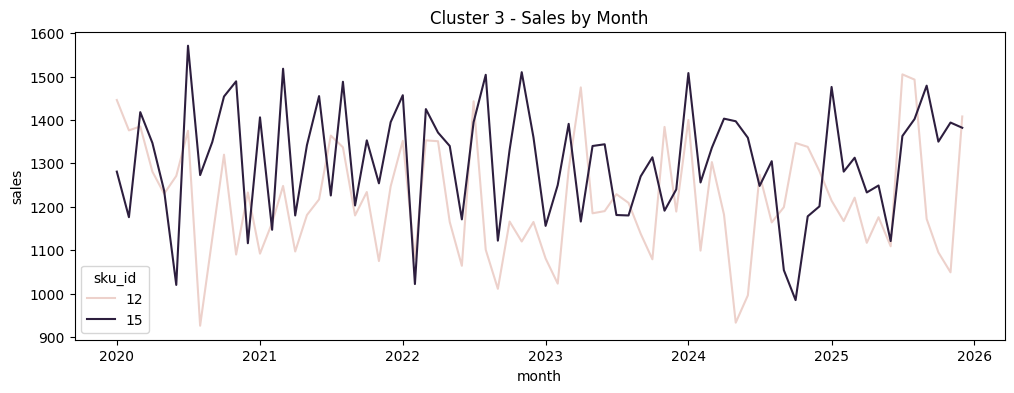

In [65]:
plot_cluster(3)

In [66]:
df_train[df_train.cluster == 3].groupby('sku_id').agg({
    'sales': ['min', 'max', 'mean', 'median', 'std'],
    'inventory_end': ['min', 'max', 'mean', 'median', 'std'],
    'lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'lag_7': ['min', 'max', 'mean', 'median', 'std'],
    'lag_14': ['min', 'max', 'mean', 'median', 'std'],
    'lag_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_7': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_90': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_std_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_std_90': ['min', 'max', 'mean', 'median', 'std'],
    'inventory_end_lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'stockout_flag_lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'days_since_stockout': ['min', 'max', 'mean', 'median', 'std']
})

sales                                   inventory_end                   \
         min  max       mean median        std           min  max        mean   
sku_id                                                                          
12         0  116  39.554844   39.0  24.127607             0  582  285.274620   
15         0  123  43.124900   43.0  22.242445             5  551  269.485188   

                          lag_1                                     lag_7  \
       median         std   min    max       mean median        std   min   
sku_id                                                                      
12      285.0  106.987489   0.0  116.0  39.533227   39.0  24.083669   0.0   
15      269.0  106.541929   0.0  123.0  43.120897   43.0  22.242377   0.0   

                                           lag_14                           \
          max       mean median        std    min    max       mean median   
sku_id                                                                       
12      116.0  39.576461   39.0  24.048544    0.0  116.0  39.541233   39.0   
15      123.0  43.160929   43.0  22.220894    0.0  123.0  43.337870   43.0   

                  lag_28                                     rolling_mean_7  \
              std    min    max       mean median        std            min   
sku_id                                                                        
12      24.099921    0.0  116.0  39.710168   39.0  24.158283      13.428571   
15      22.209186    0.0  123.0  43.318655   43.0  22.189654      19.428571   

                                                  rolling_mean_28             \
              max       mean     median       std             min        max   
sku_id                                                                         
12      69.285714  39.520188  39.428571  8.891201       27.428571  53.428571   
15      65.142857  43.113119  43.428571  8.413689       28.785714  53.857143   

                                       rolling_mean_90                        \
             mean     median       std             min        max       mean   
sku_id                                                                         
12      39.585354  39.464286  4.271449       34.422222  46.988889  39.771675   
15      43.264955  43.500000  4.478404       39.200000  47.322222  43.310791   

                            rolling_std_28                                   \
           median       std            min        max       mean     median   
sku_id                                                                        
12      39.411111  2.490926      16.933538  31.319716  23.977708  23.853028   
15      43.377778  1.420484      14.761015  29.800638  21.997105  21.989987   

                 rolling_std_90                                             \
             std            min        max       mean     median       std   
sku_id                                                                       
12      2.888145      19.825896  28.024078  24.053751  23.990312  1.558912   
15      2.512023      19.434592  25.780539  22.147997  22.083886  1.205393   

       inventory_end_lag_1                                        \
                       min    max        mean median         std   
sku_id                                                             
12                     0.0  582.0  285.182546  285.0  106.993284   
15                     5.0  551.0  269.473979  269.0  106.556298   

       stockout_flag_lag_1                             days_since_stockout  \
                       min  max      mean median   std                 min   
sku_id                                                                       
12                     0.0  1.0  0.001601    0.0  0.04                 0.0   
15                     0.0  0.0  0.000000    0.0  0.00                 0.0   

                                              
          max        mean median         std  
sku_id       

In [67]:
std3, model3 = run_model(3)

0:	learn: 23.2353524	test: 24.0179162	best: 24.0179162 (0)	total: 984us	remaining: 983ms
100:	learn: 21.2909808	test: 24.0625203	best: 23.9458606 (25)	total: 74.6ms	remaining: 664ms
200:	learn: 19.9273513	test: 24.2334588	best: 23.9458606 (25)	total: 154ms	remaining: 611ms
Stopped by overfitting detector  (200 iterations wait)

bestTest = 23.94586056
bestIteration = 25

Shrink model to first 26 iterations.

Validation RMSE: 23.9459
Test RMSE: 22.8038


### Model Cluster 4

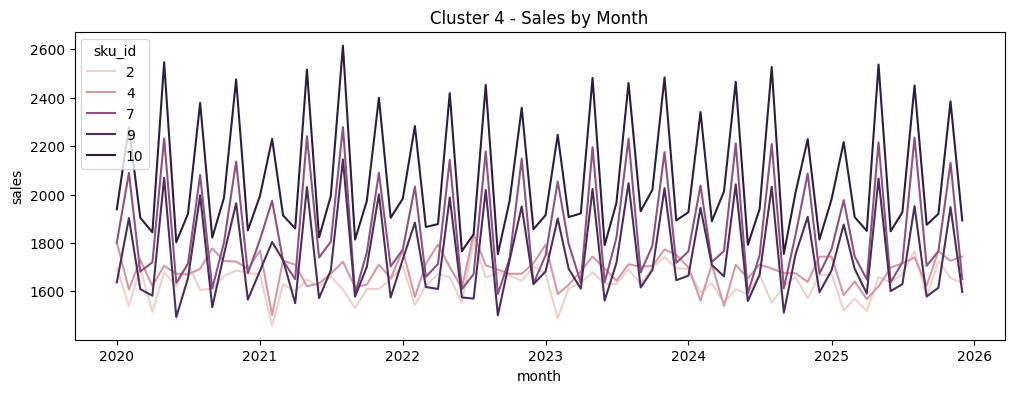

In [68]:
plot_cluster(4)

In [69]:
df_train[df_train.cluster == 4].groupby('sku_id').agg({
    'sales': ['min', 'max', 'mean', 'median', 'std'],
    'inventory_end': ['min', 'max', 'mean', 'median', 'std'],
    'lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'lag_7': ['min', 'max', 'mean', 'median', 'std'],
    'lag_14': ['min', 'max', 'mean', 'median', 'std'],
    'lag_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_7': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_mean_90': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_std_28': ['min', 'max', 'mean', 'median', 'std'],
    'rolling_std_90': ['min', 'max', 'mean', 'median', 'std'],
    'inventory_end_lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'stockout_flag_lag_1': ['min', 'max', 'mean', 'median', 'std'],
    'days_since_stockout': ['min', 'max', 'mean', 'median', 'std']
})

sales                                   inventory_end                   \
         min  max       mean median        std           min  max        mean   
sku_id                                                                          
2         25   85  53.705364   54.0   9.823995            95  592  354.500400   
4         23   91  55.461970   56.0  10.280616            27  564  293.838271   
7         25   94  60.861489   61.0  12.710630            32  586  299.386709   
9         18   93  57.451561   57.0  11.460961            27  603  322.068855   
10        23  111  67.919135   68.0  14.681142             0  765  387.473179   

                          lag_1                                     lag_7  \
       median         std   min    max       mean median        std   min   
sku_id                                                                      
2       354.0  119.756137  25.0   85.0  53.687750   54.0   9.792896  25.0   
4       294.0  124.140343  23.0   83.0  55.434748   56.0  10.231336  23.0   
7       303.0  134.031654  25.0   94.0  60.836669   61.0  12.701538  25.0   
9       320.0  129.733109  18.0   93.0  57.435548   57.0  11.457386  18.0   
10      390.0  163.921327  23.0  111.0  67.883907   68.0  14.661681  23.0   

                                           lag_14                           \
          max       mean median        std    min    max       mean median   
sku_id                                                                       
2        85.0  53.652522   54.0   9.774837   25.0   85.0  53.668535   54.0   
4        83.0  55.416333   56.0  10.225248   23.0   83.0  55.437950   56.0   
7        94.0  60.730184   61.0  12.735225   25.0   94.0  60.633307   61.0   
9        93.0  57.368295   57.0  11.461914   18.0   93.0  57.287430   57.0   
10      111.0  67.781425   68.0  14.679463   23.0  111.0  67.714171   68.0   

                  lag_28                                     rolling_mean_7  \
              std    min    max       mean median        std            min   
sku_id                                                                        
2        9.773262   25.0   85.0  53.678943   54.0   9.765449      41.571429   
4       10.211366   23.0   83.0  55.446757   56.0  10.212279      42.857143   
7       12.688579   25.0   94.0  60.452362   61.0  12.600920      39.000000   
9       11.456013   18.0   93.0  57.133707   57.0  11.379408      37.285714   
10      14.660063   23.0  111.0  67.517214   67.0  14.578091      41.000000   

                                                   rolling_mean_28             \
              max       mean     median        std             min        max   
sku_id                                                                          
2       66.428571  53.677914  53.571429   3.807730       49.035714  58.678571   
4       67.000000  55.427885  55.428571   4.049932       50.892857  61.142857   
7       82.000000  60.786572  61.142857   9.719456       46.250000  74.928571   
9       77.285714  57.407412  57.142857   7.977526       44.285714  69.678571   
10      97.142857  67.848793  68.285714  11.524034       50.321429  85.142857   

                                       rolling_mean_90                        \
             mean     median       std             min        max       mean   
sku_id                                                                         
2       53.678772  53.642857  1.745321       51.544444  56.211111  53.710417   
4       55.439723  55.357143  1.795758       53.188889  57.422222  55.497918   
7       60.625672  60.678571  7.976009       58.033333  63.266667  60.683747   
9       57.270045  57.000000  6.477674       54.977778  59.466667  57.279779   
10      67.694870  67.607143  9.509615       64.488889  70.566667  67.747709   

                            rolling_std_28                                   \
           median       std            min        max       mean     median   
sku_id                             

In [70]:
std4, model4 = run_model(4)

0:	learn: 12.7091347	test: 12.1952635	best: 12.1952635 (0)	total: 2.48ms	remaining: 2.48s
100:	learn: 9.6061099	test: 9.5647456	best: 9.5647456 (100)	total: 318ms	remaining: 2.83s
200:	learn: 9.3180047	test: 9.5249529	best: 9.5249529 (200)	total: 614ms	remaining: 2.44s
300:	learn: 9.0347796	test: 9.5412920	best: 9.5246674 (202)	total: 923ms	remaining: 2.14s
400:	learn: 8.7682349	test: 9.5519036	best: 9.5246674 (202)	total: 1.2s	remaining: 1.79s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 9.524667409
bestIteration = 202

Shrink model to first 203 iterations.

Validation RMSE: 9.5247
Test RMSE: 9.5305


# Inventory Policy Backtest

Forecast accuracy alone is not sufficient to determine whether a forecasting solution generates business value. In supply chain applications, the ultimate objective is to improve inventory decisions while balancing product availability and inventory carrying costs.

To evaluate the practical impact of the proposed forecasting approach, a backtest simulation is performed on the test dataset. The simulation emulates how the forecasting models would have been used in a real production environment to support replenishment decisions.

Every 30 days, demand forecasts are generated for each SKU and used to calculate new inventory parameters, including safety stock, reorder points, and order-up-to levels. These parameters are then applied during the subsequent period, and inventory levels are simulated day by day while respecting lead times and replenishment constraints.

Because historical sales may be censored by stockouts, demand is reconstructed during periods of inventory shortages using model predictions as a proxy for unobserved demand. This allows the simulation to estimate the true impact of stockouts on service levels and inventory costs.

The performance of the proposed policy is then compared against the original inventory policy by measuring two key cost components:

* **Holding Cost:** the cost of carrying inventory over time.
* **Stockout Cost:** the estimated cost associated with unmet demand.

The final outcome of the backtest is the total cost generated by each policy, allowing us to quantify the economic value of the forecasting-driven replenishment strategy and assess whether it provides a better balance between inventory investment and customer service.


In [ ]:

def simulate_new_policy(
    df,
    test_date,
    model_rmse,
    model,
    features,
    service_level=0.90,
    coverage_days=3,
    review_period = 30
):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    test_date = pd.to_datetime(test_date)

    df = df.sort_values(["sku_id", "date"]).reset_index(drop=True)
    

    # Accept both 0.90 and 90 as valid inputs
    if service_level > 1:
        service_level = service_level / 100

    service_level_z = norm.ppf(service_level)
    output = []

    def build_next_features(history, prediction_date, sku_id):
        history = history.sort_values("date")
        sales = history["sales"]

        feature_row = {
            "sku_id": sku_id,
            "month": prediction_date.month,
            "quarter": prediction_date.quarter,
            "week_of_year": int(prediction_date.isocalendar().week),
            "day_of_year": prediction_date.dayofyear,
            "month_sin": np.sin(2 * np.pi * prediction_date.month / 12),
            "month_cos": np.cos(2 * np.pi * prediction_date.month / 12),

            "lag_1": sales.iloc[-1],
            "lag_7": sales.iloc[-7],
            "lag_14": sales.iloc[-14],
            "lag_28": sales.iloc[-28],

            "rolling_mean_7": sales.iloc[-7:].mean(),
            "rolling_mean_28": sales.iloc[-28:].mean(),
            "rolling_mean_90": sales.iloc[-90:].mean(),

            "rolling_std_28": sales.iloc[-28:].std(),
            "rolling_std_90": sales.iloc[-90:].std(),

            "inventory_end_lag_1": history["inventory_end"].iloc[-1],
            "stockout_flag_lag_1": history["stockout_flag"].iloc[-1],
            "days_since_stockout": (
                history["days_since_stockout"].iloc[-1]
                if "days_since_stockout" in history.columns
                else 0
            )
        }

        return pd.DataFrame([{col: feature_row[col] for col in features}])

    for sku_id, sku_df in df.groupby("sku_id"):

        sku_df = sku_df.sort_values("date").reset_index(drop=True)
        history = sku_df[sku_df["date"] < test_date].copy()
        test = sku_df[sku_df["date"] >= test_date].copy().reset_index(drop=True)

        if history.empty or test.empty:
            continue

        inventory = float(history["inventory_end"].iloc[-1])
        pending_orders = []

        lead_time = int(sku_df["lead_time"].iloc[0])

        for chunk_start in range(0, len(test), review_period):

            chunk = test.iloc[chunk_start:chunk_start + review_period].copy()
            cycle_start = chunk["date"].iloc[0]
            cycle_end = chunk["date"].iloc[-1]

            temp_history = history.copy()
            policy_predictions = []

            for current_date in chunk["date"]:

                X_pred = build_next_features(
                    history=temp_history,
                    prediction_date=current_date,
                    sku_id=sku_id
                )

                prediction = max(0, float(model.predict(X_pred)[0]))
                policy_predictions.append(prediction)

                temp_row = temp_history.iloc[-1].copy()
                temp_row["date"] = current_date
                temp_row["sales"] = prediction
                temp_row["inventory_end"] = inventory
                temp_row["stockout_flag"] = 0

                temp_history = pd.concat(
                    [temp_history, pd.DataFrame([temp_row])],
                    ignore_index=True
                )

            policy_predictions = np.array(policy_predictions)
            mean_forecast_30d = policy_predictions.mean()
            std_forecast_30d = policy_predictions.std(ddof=1)

            if np.isnan(std_forecast_30d):
                std_forecast_30d = 0

            lead_time_demand = mean_forecast_30d * lead_time

            daily_demand_std = np.sqrt(
                model_rmse ** 2 + std_forecast_30d ** 2
            )

            new_safety_stock = (
                service_level_z
                * daily_demand_std
                * np.sqrt(lead_time)
            )

            new_reorder_point = lead_time_demand + new_safety_stock

            new_order_up_to_level = (
                new_reorder_point
                + mean_forecast_30d * coverage_days
            )

            for _, row in chunk.iterrows():

                current_date = row["date"]
                replenishment_qty = 0
                received_orders = []

                for arrival_date, qty in pending_orders:
                    if arrival_date <= current_date:
                        replenishment_qty += qty
                        inventory += qty
                        received_orders.append((arrival_date, qty))

                pending_orders = [
                    order for order in pending_orders
                    if order not in received_orders
                ]

                X_pred = build_next_features(
                    history=history,
                    prediction_date=current_date,
                    sku_id=sku_id
                )

                prediction = max(0, float(model.predict(X_pred)[0]))

                if row["stockout_flag"] == 1:
                    reconstructed_demand = max(float(row["sales"]), prediction)
                else:
                    reconstructed_demand = float(row["sales"])

                inventory_start = inventory
                simulated_sales = min(reconstructed_demand, inventory_start)
                simulated_lost_sales = max(reconstructed_demand - inventory_start, 0)

                inventory = inventory_start - simulated_sales
                simulated_stockout_flag = int(simulated_lost_sales > 0)
                inventory_position = inventory + sum(qty for _, qty in pending_orders)

                if inventory_position <= new_reorder_point:
                    order_qty = max(new_order_up_to_level - inventory_position, 0)
                    arrival_date = current_date + pd.Timedelta(days=lead_time)
                    pending_orders.append((arrival_date, order_qty))
                else:
                    order_qty = 0

                output_row = row.to_dict()

                output_row.update({
                    "prediction": prediction,
                    "reconstructed_demand": reconstructed_demand,

                    "simulated_inventory_start": inventory_start,
                    "simulated_inventory_end": inventory,
                    "simulated_replenishment_qty": replenishment_qty,
                    "simulated_order_qty": order_qty,
                    "simulated_stockout_flag": simulated_stockout_flag,
                    "simulated_lost_sales": simulated_lost_sales,

                    "mean_forecast_30d": mean_forecast_30d,
                    "std_forecast_30d": std_forecast_30d,
                    "daily_demand_std": daily_demand_std,

                    "service_level": service_level,
                    "service_level_z": service_level_z,
                    "coverage_days": coverage_days,

                    "new_safety_stock": new_safety_stock,
                    "new_reorder_point": new_reorder_point,
                    "new_order_up_to_level": new_order_up_to_level,

                    "policy_cycle_start": cycle_start,
                    "policy_cycle_end": cycle_end
                })

                output.append(output_row)

                new_history_row = row.copy()
                new_history_row["sales"] = reconstructed_demand
                new_history_row["inventory_end"] = inventory
                new_history_row["replenishment_qty"] = replenishment_qty
                new_history_row["stockout_flag"] = simulated_stockout_flag

                history = pd.concat(
                    [history, pd.DataFrame([new_history_row])],
                    ignore_index=True
                )

    return pd.DataFrame(output)

In [72]:
cluster_0 = simulate_new_policy(df[df.cluster == 0], test_date, std0, model0, features)
cluster_1 = simulate_new_policy(df[df.cluster == 1], test_date, std1, model1, features)
cluster_2 = simulate_new_policy(df[df.cluster == 2], test_date, std2, model2, features)
cluster_3 = simulate_new_policy(df[df.cluster == 3], test_date, std3, model3, features)
cluster_4 = simulate_new_policy(df[df.cluster == 4], test_date, std4, model4, features)

In [73]:
df_simulation = pd.concat([cluster_0, cluster_1, cluster_2, cluster_3, cluster_4])
df_simulation.sort_values(["sku_id", "date"], inplace=True)

To evaluate the economic impact of different inventory policies, a synthetic financial dataset is created containing holding costs and stockout costs for each SKU. Since no real financial information is available, the costs are generated using the SKU's base demand as a proxy for product importance and sales volume. Products with higher demand generally represent larger inventory investments and greater business impact, making them reasonable candidates for higher associated costs.

The holding cost represents the expense of carrying one unit of inventory over time and is generated as a small fraction of the SKU's average demand level. The stockout cost represents the financial impact of unmet demand, including lost sales and customer service degradation, and is intentionally set much higher than the holding cost. This reflects the common supply chain assumption that inventory shortages are typically more expensive than storing additional inventory. 

In [74]:

def generate_financial_data(df, rng=None):
    """
    Generate synthetic holding and stockout costs per SKU.

    Parameters
    ----------
    df : pd.DataFrame
        Original simulation dataframe.
    rng : np.random.Generator

    Returns
    -------
    pd.DataFrame
    """

    if rng is None:
        rng = np.random.default_rng(42)

    sku_data = (
        df
        .groupby("sku_id")
        .agg(
            category=("category", "first"),
            demand_type=("demand_type", "first"),
            base_demand=("base_demand", "first")
        )
        .reset_index()
    )

    records = []

    for _, row in sku_data.iterrows():

        # Monthly carrying cost of holding 1 unit
        holding_cost = (
            row["base_demand"]
            * rng.uniform(0.01, 0.05)
        )

        # Lost sales / customer service penalty
        stockout_cost = (
            row["base_demand"]
            * rng.uniform(5, 20)
        )

        records.append({
            "sku_id": row["sku_id"],
            "holding_cost": round(holding_cost, 2),
            "stockout_cost": round(stockout_cost, 2)
        })

    return pd.DataFrame(records)

df_financial = generate_financial_data(df)
df_financial.head()

,sku_id,holding_cost,stockout_cost
0,1,1.56,440.16
1,2,2.39,834.87
2,3,0.37,530.13
3,4,2.26,940.29
4,5,0.64,493.74


In [76]:
def compare_policy_costs(df_simulation, df_costs):
    df_eval = df_simulation.merge(
        df_costs,
        on="sku_id",
        how="left"
    )

    # Historical policy
    df_eval["historical_reconstructed_demand"] = np.where(
        df_eval["stockout_flag"] == 1,
        np.maximum(df_eval["sales"], df_eval["prediction"]),
        df_eval["sales"]
    )

    df_eval["historical_lost_sales"] = (
        df_eval["historical_reconstructed_demand"] - df_eval["sales"]
    ).clip(lower=0)

    df_eval["historical_holding_cost"] = (
        df_eval["inventory_end"] * df_eval["holding_cost"]
    )

    df_eval["historical_stockout_cost"] = (
        df_eval["historical_lost_sales"] * df_eval["stockout_cost"]
    )

    df_eval["historical_total_cost"] = (
        df_eval["historical_holding_cost"]
        + df_eval["historical_stockout_cost"]
    )

    # New simulated policy
    df_eval["simulated_holding_cost"] = (
        df_eval["simulated_inventory_end"] * df_eval["holding_cost"]
    )

    df_eval["simulated_stockout_cost"] = (
        df_eval["simulated_lost_sales"] * df_eval["stockout_cost"]
    )

    df_eval["simulated_total_cost"] = (
        df_eval["simulated_holding_cost"]
        + df_eval["simulated_stockout_cost"]
    )

    # Service level / fill rate
    historical_total_demand = df_eval["historical_reconstructed_demand"].sum()
    historical_fulfilled_demand = (
        df_eval["historical_reconstructed_demand"]
        - df_eval["historical_lost_sales"]
    ).sum()

    simulated_total_demand = df_eval["reconstructed_demand"].sum()
    simulated_fulfilled_demand = (
        df_eval["reconstructed_demand"]
        - df_eval["simulated_lost_sales"]
    ).sum()

    historical_service_level = (
        historical_fulfilled_demand / historical_total_demand
        if historical_total_demand > 0
        else 0
    )

    simulated_service_level = (
        simulated_fulfilled_demand / simulated_total_demand
        if simulated_total_demand > 0
        else 0
    )

    summary = pd.DataFrame({
        "policy": ["historical_policy", "new_policy"],
        "holding_cost": [
            df_eval["historical_holding_cost"].sum(),
            df_eval["simulated_holding_cost"].sum()
        ],
        "stockout_cost": [
            df_eval["historical_stockout_cost"].sum(),
            df_eval["simulated_stockout_cost"].sum()
        ],
        "total_cost": [
            df_eval["historical_total_cost"].sum(),
            df_eval["simulated_total_cost"].sum()
        ],
        "stockout_events": [
            df_eval["stockout_flag"].sum(),
            df_eval["simulated_stockout_flag"].sum()
        ],
        "lost_sales": [
            df_eval["historical_lost_sales"].sum(),
            df_eval["simulated_lost_sales"].sum()
        ],
        "total_demand": [
            historical_total_demand,
            simulated_total_demand
        ],
        "fulfilled_demand": [
            historical_fulfilled_demand,
            simulated_fulfilled_demand
        ],
        "service_level": [
            historical_service_level,
            simulated_service_level
        ]
    })

    historical_cost = summary.loc[
        summary["policy"] == "historical_policy",
        "total_cost"
    ].iloc[0]

    new_cost = summary.loc[
        summary["policy"] == "new_policy",
        "total_cost"
    ].iloc[0]

    historical_sl = summary.loc[
        summary["policy"] == "historical_policy",
        "service_level"
    ].iloc[0]

    new_sl = summary.loc[
        summary["policy"] == "new_policy",
        "service_level"
    ].iloc[0]

    economy = historical_cost - new_cost
    economy_pct = economy / historical_cost if historical_cost > 0 else 0

    service_level_delta = new_sl - historical_sl

    winner = "new_policy" if new_cost < historical_cost else "historical_policy"

    print("Policy Cost Comparison")
    print("----------------------")
    print(summary.round(4))

    print("\nResult")
    print("------")
    print(f"Historical policy total cost: {historical_cost:,.2f}")
    print(f"New policy total cost: {new_cost:,.2f}")
    print(f"Economy generated: {economy:,.2f}")
    print(f"Economy percentage: {economy_pct:.2%}")
    print(f"Historical service level: {historical_sl:.2%}")
    print(f"New policy service level: {new_sl:.2%}")
    print(f"Service level delta: {service_level_delta:.2%}")
    print(f"Winning policy: {winner}")

    return df_eval, summary

df_eval, summary = compare_policy_costs(df_simulation, df_financial)

Policy Cost Comparison
----------------------
              policy  holding_cost  stockout_cost    total_cost  \
0  historical_policy  2.889306e+06   1.596458e+04  2.905271e+06   
1         new_policy  1.330498e+06   1.230175e+06  2.560673e+06   

   stockout_events  lost_sales  total_demand  fulfilled_demand  service_level  
0               49     63.9991   358008.9991        357945.000         0.9998  
1              192   2782.5261   358008.9991        355226.473         0.9922  

Result
------
Historical policy total cost: 2,905,270.63
New policy total cost: 2,560,672.75
Economy generated: 344,597.88
Economy percentage: 11.86%
Historical service level: 99.98%
New policy service level: 99.22%
Service level delta: -0.76%
Winning policy: new_policy
